In [53]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Change this if the metrics CSV lives elsewhere
RESULT_CSV = Path("new_result.csv")

In [54]:
if not RESULT_CSV.exists():
    raise FileNotFoundError(f"{RESULT_CSV} not found. Run multi-eval.py --all-ids --save-csv first.")

print(f"Loading metrics from {RESULT_CSV.resolve()}")
df = pd.read_csv(RESULT_CSV)
cols_to_drop = [c for c in ["qafacteval_available", "qafacteval_score"] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df.head()

Loading metrics from S:\UCKG2.0\UCKG\qa-engine\evaluation\new_result.csv


,id,rouge1_f1,rouge2_f1,rougeLsum_f1,bleu1,bleu2,bleu3,bleu4,bertscore_p,bertscore_r,bertscore_f1,bertscore_precision_only
0,1,0.594059,0.437811,0.480198,0.503937,0.418667,0.378568,0.353202,0.188964,0.264219,0.228601,0.188964
1,2,0.517544,0.229075,0.267544,0.374593,0.215680,0.134632,0.086580,0.068094,0.181124,0.125447,0.068094
2,3,0.512438,0.250000,0.303483,0.431227,0.294769,0.237181,0.207558,0.135495,0.162724,0.152373,0.135495
3,4,0.438228,0.149883,0.279720,0.337705,0.188541,0.123357,0.083974,0.101393,0.199772,0.152006,0.101393
4,5,0.455982,0.231293,0.329571,0.365132,0.247907,0.190553,0.160683,0.126937,0.160098,0.146728,0.126937


In [55]:
def classify(id_value):
    if 1 <= id_value <= 50:
        return "Type 0"
    elif 51 <= id_value <= 70:
        return "Type 1"
    elif 76 <= id_value <= 101:
        return "Type 1"
    elif 71 <= id_value <= 75:
        return "Type 2"
    elif 102 <= id_value <= 151:
        return "Type 2"
    else:
        return "Out of range"

df["type"] = df["id"].apply(classify)

rouge_cols = ["rouge1_f1", "rouge2_f1", "rougeLsum_f1"]
bleu_cols = ["bleu1", "bleu2", "bleu3", "bleu4"]
bertscore_cols= ["bertscore_f1"]

avg_rouge_all = df.groupby("type")[rouge_cols].mean()
avg_rouge_overall = avg_rouge_all.mean(axis=1)

avg_bleu_all = df.groupby("type")[bleu_cols].mean()
avg_bleu_overall = avg_bleu_all.mean(axis=1)

avg_bertscore_f1 = df.groupby("type")[bertscore_cols].mean()

# Create summary dataframe
summary_df = pd.DataFrame({
    'ROUGE': avg_rouge_overall,
    'BLEU': avg_bleu_overall,
    'BERTScore F1': avg_bertscore_f1['bertscore_f1']
})

print("Summary Statistics by Type:")
print("=" * 50)
print(summary_df.round(4))
print("\n" + "=" * 50)
print(f"\nTotal samples: {len(df)}")
print(f"Samples per type:\n{df['type'].value_counts().sort_index()}")

summary_df

Summary Statistics by Type:
         ROUGE    BLEU  BERTScore F1
type                                
Type 0  0.2137  0.1285        0.0654
Type 1  0.1736  0.0992        0.0624
Type 2  0.1783  0.0657        0.0287


Total samples: 151
Samples per type:
type
Type 0    50
Type 1    46
Type 2    55
Name: count, dtype: int64


,ROUGE,BLEU,BERTScore F1
type,,,
Type 0,0.213650,0.128537,0.065426
Type 1,0.173588,0.099202,0.062407
Type 2,0.178346,0.065722,0.028672


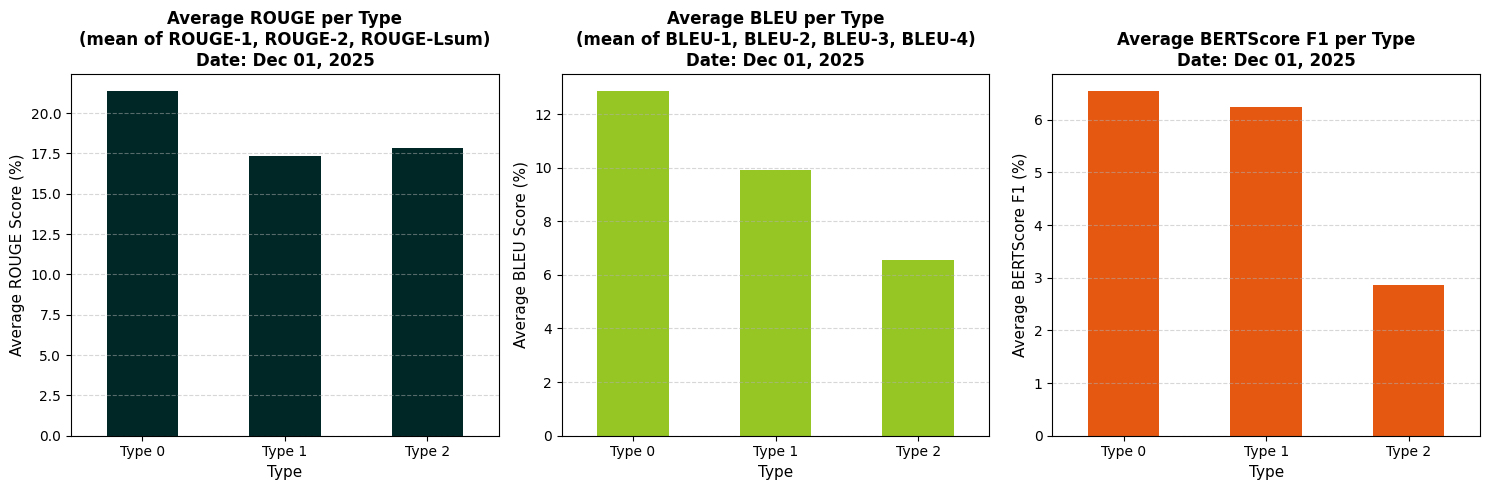

In [56]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ensure Type 0, Type 1, Type 2 order
type_order = ['Type 0', 'Type 1', 'Type 2']
avg_rouge_sorted = avg_rouge_overall.reindex(type_order) * 100  # Convert to percentage
avg_bleu_sorted = avg_bleu_overall.reindex(type_order) * 100  # Convert to percentage
avg_bertscore_sorted = avg_bertscore_f1['bertscore_f1'].reindex(type_order) * 100  # Convert to percentage

# ROUGE Chart - Vertical bars
avg_rouge_sorted.plot(kind="bar", ax=axes[0], color='#002626')
axes[0].set_xlabel("Type", fontsize=11)
axes[0].set_ylabel("Average ROUGE Score (%)", fontsize=11)
axes[0].set_title("Average ROUGE per Type\n(mean of ROUGE-1, ROUGE-2, ROUGE-Lsum)\nDate: Dec 01, 2025", fontsize=12, fontweight='bold')
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# BLEU Chart - Vertical bars
avg_bleu_sorted.plot(kind="bar", ax=axes[1], color='#95C623')
axes[1].set_xlabel("Type", fontsize=11)
axes[1].set_ylabel("Average BLEU Score (%)", fontsize=11)
axes[1].set_title("Average BLEU per Type\n(mean of BLEU-1, BLEU-2, BLEU-3, BLEU-4)\nDate: Dec 01, 2025", fontsize=12, fontweight='bold')
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# BERTScore Chart - Vertical bars
avg_bertscore_sorted.plot(kind="bar", ax=axes[2], color='#E55812')
axes[2].set_xlabel("Type", fontsize=11)
axes[2].set_ylabel("Average BERTScore F1 (%)", fontsize=11)
axes[2].set_title("Average BERTScore F1 per Type\nDate: Dec 01, 2025", fontsize=12, fontweight='bold')
axes[2].grid(axis="y", linestyle="--", alpha=0.5)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('result-each-metric.png', dpi=150, bbox_inches='tight')
plt.show()

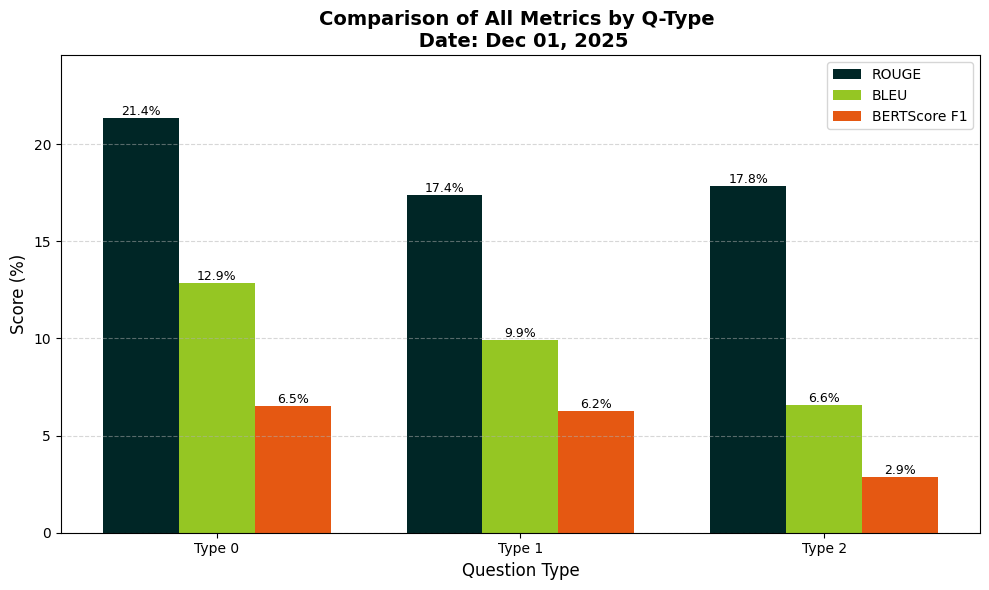

In [57]:
# Combined comparison chart - Normal bar chart with percentage scores
fig, ax = plt.subplots(figsize=(10, 6))

# Convert scores to percentages
rouge_pct = summary_df['ROUGE'] * 100
bleu_pct = summary_df['BLEU'] * 100
bertscore_pct = summary_df['BERTScore F1'] * 100

# Ensure Type 0, Type 1, Type 2 order
type_order = ['Type 0', 'Type 1', 'Type 2']
rouge_pct = rouge_pct.reindex(type_order)
bleu_pct = bleu_pct.reindex(type_order)
bertscore_pct = bertscore_pct.reindex(type_order)

x = np.arange(len(type_order))
width = 0.25

# Create vertical bars
bars1 = ax.bar(x - width, rouge_pct, width, label='ROUGE', color='#002626')
bars2 = ax.bar(x, bleu_pct, width, label='BLEU', color='#95C623')
bars3 = ax.bar(x + width, bertscore_pct, width, label='BERTScore F1', color='#E55812')

ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparison of All Metrics by Q-Type \n Date: Dec 01, 2025', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(rouge_pct.index)  # Type 0, Type 1, Type 2
ax.legend(loc='upper right')
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, max(rouge_pct.max(), bleu_pct.max(), bertscore_pct.max()) * 1.15)

# Add value labels on bars (as percentages)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('result-overall.png', dpi=150, bbox_inches='tight')
plt.show()


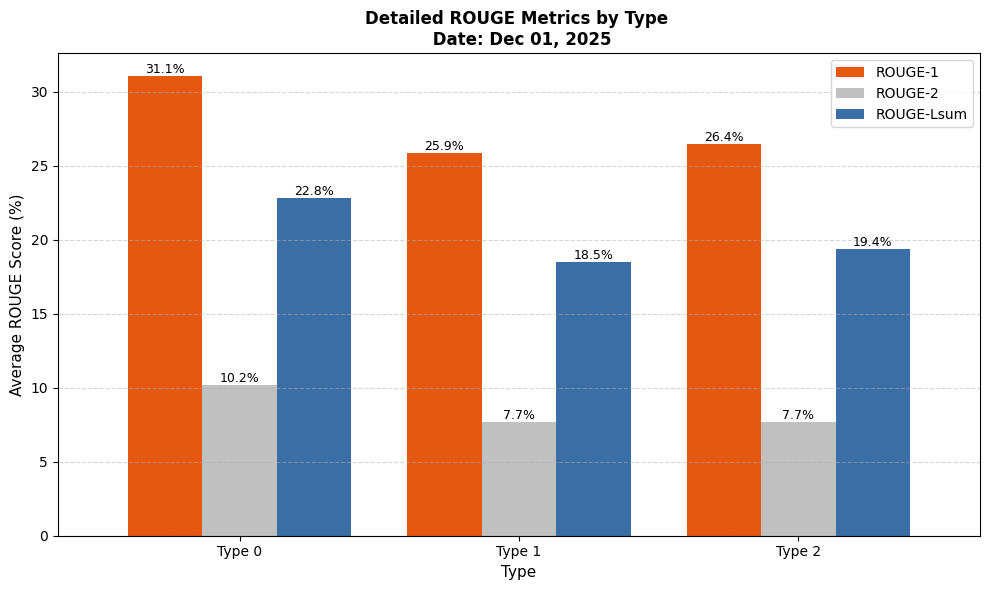

In [58]:
# Detailed breakdown: Individual ROUGE metrics
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure Type 0, Type 1, Type 2 order
type_order = ['Type 0', 'Type 1', 'Type 2']
avg_rouge_all_sorted = avg_rouge_all.reindex(type_order) * 100  # Convert to percentage

# Color scheme matching main ROUGE chart
rouge_colors = ['#E55812', '#C0C0C0', '#3A6EA5']

avg_rouge_all_sorted.plot(kind="bar", ax=ax, width=0.8, color=rouge_colors)
ax.set_xlabel("Type", fontsize=11)
ax.set_ylabel("Average ROUGE Score (%)", fontsize=11)
ax.set_title("Detailed ROUGE Metrics by Type \n Date: Dec 01, 2025", fontsize=12, fontweight='bold')
ax.legend(['ROUGE-1', 'ROUGE-2', 'ROUGE-Lsum'], loc='upper right')
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add value labels on bars (as percentages)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('result-rouge.png', dpi=150, bbox_inches='tight')
plt.show()


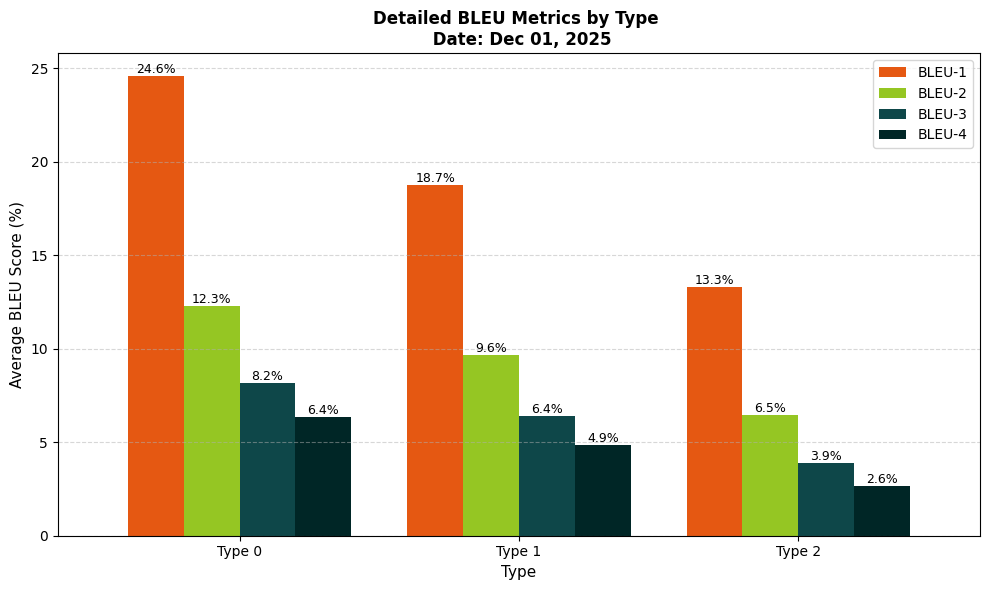

In [59]:
# Detailed breakdown: Individual BLEU metrics
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure Type 0, Type 1, Type 2 order
type_order = ['Type 0', 'Type 1', 'Type 2']
avg_bleu_all_sorted = avg_bleu_all.reindex(type_order) * 100  # Convert to percentage

# Color scheme matching main BLEU chart
bleu_colors = ['#E55812', '#95C623', '#0E4749', '#002626'] 
avg_bleu_all_sorted.plot(kind="bar", ax=ax, width=0.8, color=bleu_colors)
ax.set_xlabel("Type", fontsize=11)
ax.set_ylabel("Average BLEU Score (%)", fontsize=11)
ax.set_title("Detailed BLEU Metrics by Type \n Date: Dec 01, 2025", fontsize=12, fontweight='bold')
ax.legend(['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'], loc='upper right')
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
# Add value labels on bars (as percentages)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('result-bleu.png', dpi=150, bbox_inches='tight')
plt.show()


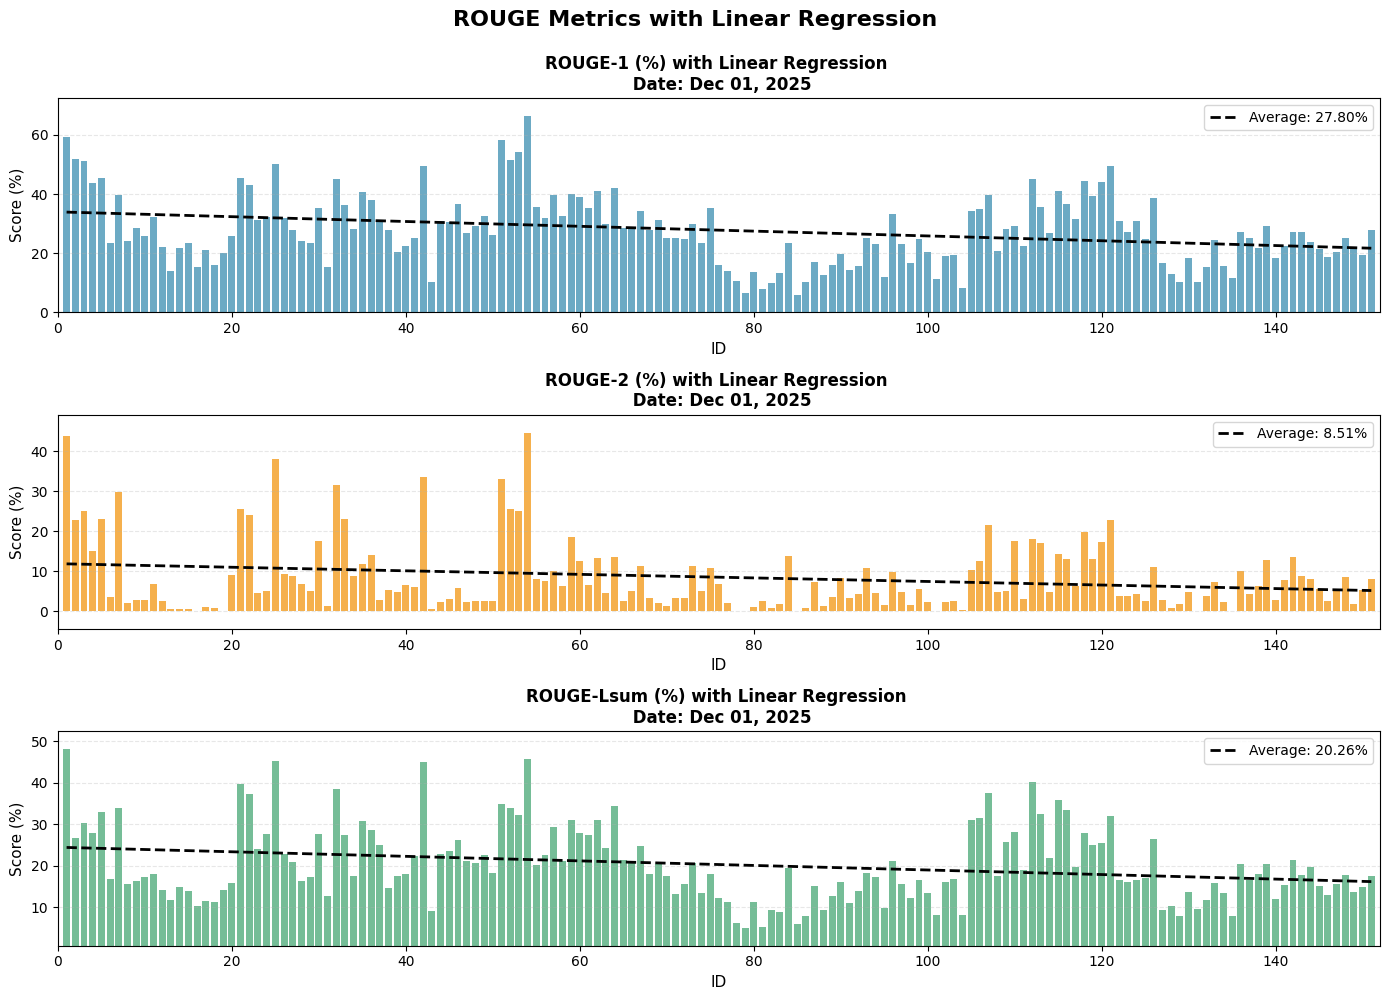

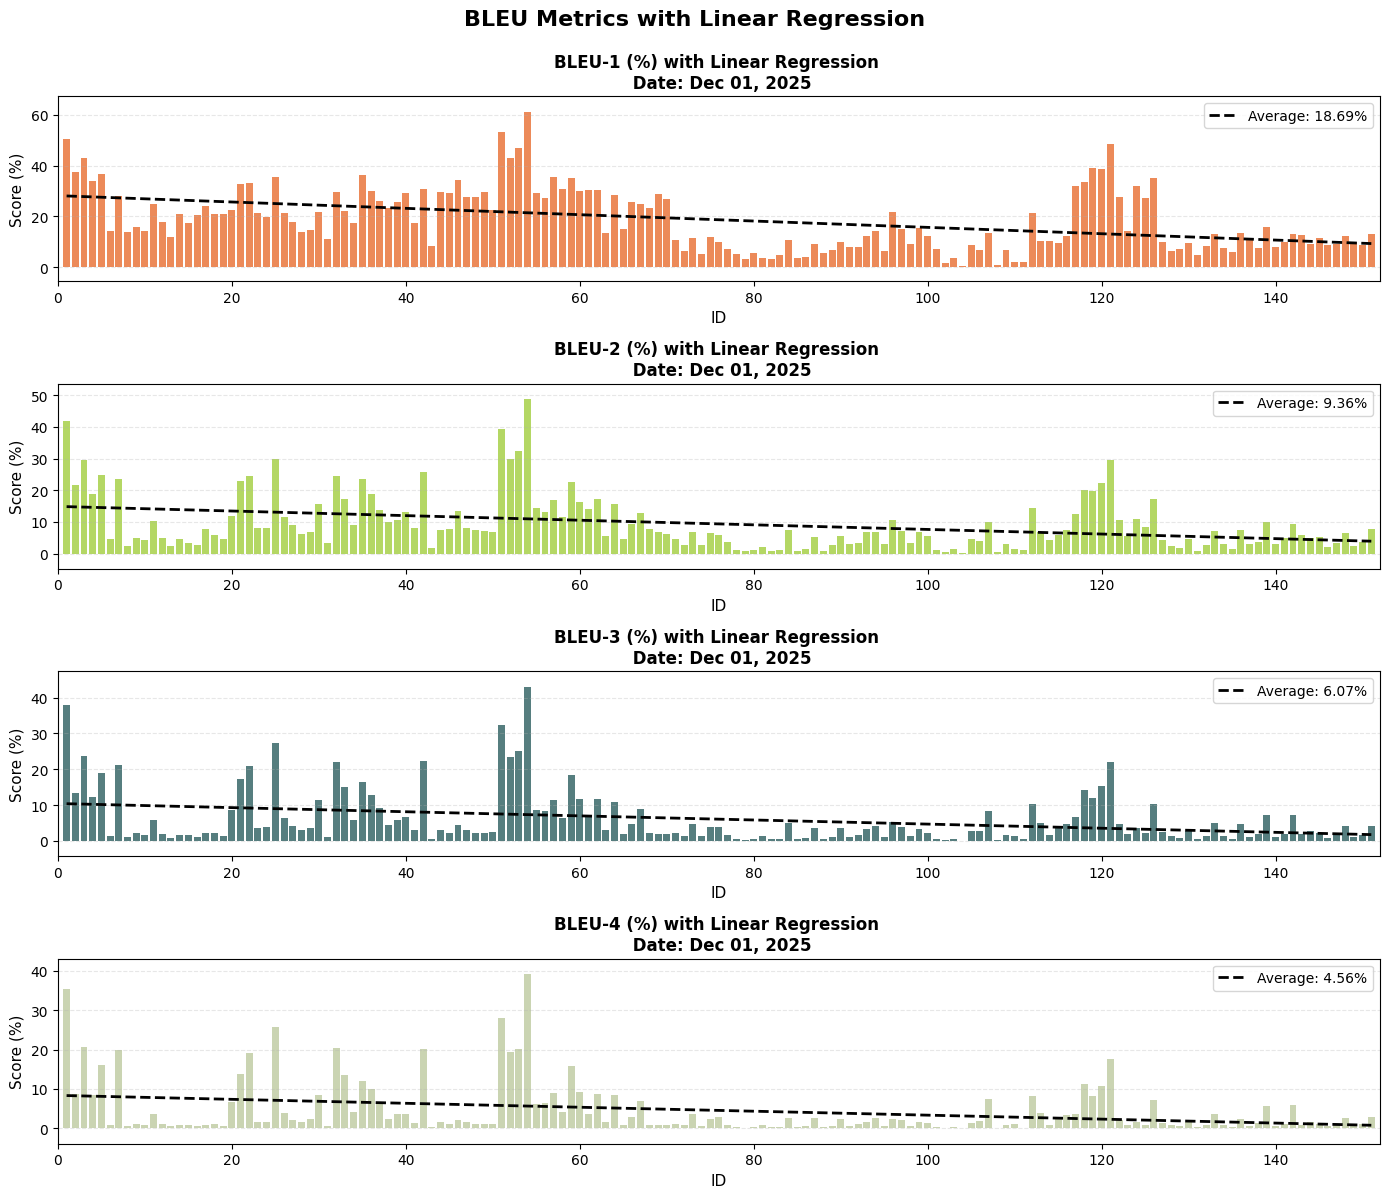

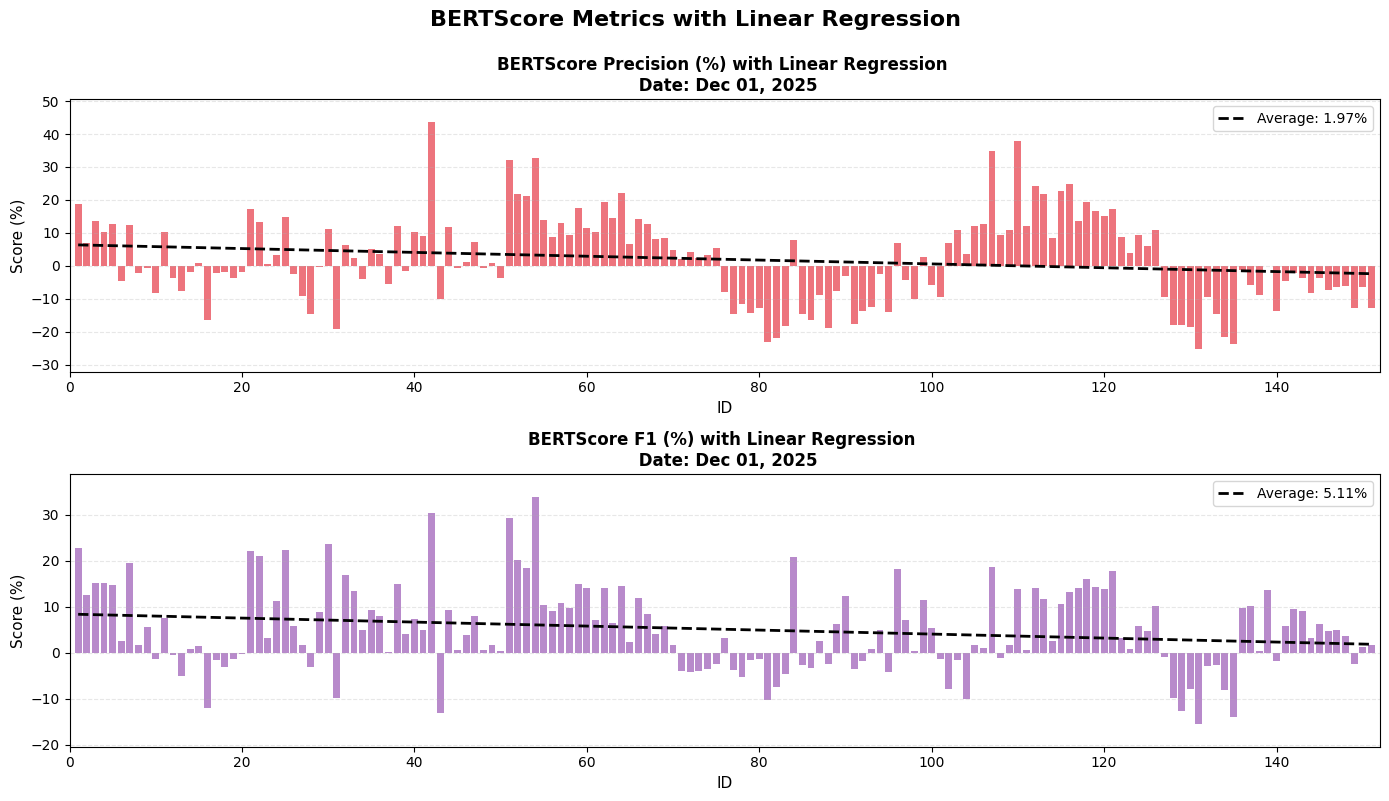

In [60]:
# Individual metric charts with linear regression analysis - Split by metric type
# Sort dataframe by ID for proper ordering
df_sorted = df.sort_values('id').copy()
ids = df_sorted['id'].values

# Helper function to create a chart for a single metric
def plot_metric_with_regression(ax, ids, data, metric_name, color):
    """Plot a single metric with bars and linear regression line."""
    # Plot bars
    ax.bar(ids, data.values, color=color, alpha=0.7, width=0.8)
    
    # Calculate linear regression
    z = np.polyfit(ids, data.values, 1)
    p = np.poly1d(z)
    regression_line = p(ids)
    
    # Plot regression line
    ax.plot(ids, regression_line, "k--", linewidth=2)
    
    # Calculate and display average
    avg_score = data.mean()
    
    # Set labels and title
    ax.set_xlabel('ID', fontsize=11)
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title(f'{metric_name} (%) with Linear Regression \n Date: Dec 01, 2025', fontsize=12, fontweight='bold')
    
    # Add legend with average score only
    ax.legend([f'Average: {avg_score:.2f}%'], loc='upper right', fontsize=10, frameon=True)
    
    # Grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_xlim(0, max(ids) + 1)
    
    # Set Y-axis limits with some padding
    y_min, y_max = data.min(), data.max()
    y_range = y_max - y_min
    if y_range > 0:
        ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
    else:
        ax.set_ylim(y_min - 5, y_max + 5)

# ============================================================================
# Figure 1: ROUGE Metrics
# ============================================================================
rouge_metrics = {
    'ROUGE-1': (df_sorted['rouge1_f1'] * 100, '#2E86AB'),
    'ROUGE-2': (df_sorted['rouge2_f1'] * 100, '#F18F01'),
    'ROUGE-Lsum': (df_sorted['rougeLsum_f1'] * 100, '#3BA26B')
}

fig1, axes1 = plt.subplots(3, 1, figsize=(14, 10))
fig1.suptitle('ROUGE Metrics with Linear Regression', fontsize=16, fontweight='bold', y=0.995)

for idx, (metric_name, (data, color)) in enumerate(rouge_metrics.items()):
    plot_metric_with_regression(axes1[idx], ids, data, metric_name, color)

plt.tight_layout()
plt.savefig('result-(1).png', dpi=150, bbox_inches='tight')
plt.show()
#print("ROUGE metrics chart saved as 'output (1).png'")

# ============================================================================
# Figure 2: BLEU Metrics
# ============================================================================
bleu_metrics = {
    'BLEU-1': (df_sorted['bleu1'] * 100, '#E55812'),  
    'BLEU-2': (df_sorted['bleu2'] * 100, '#95C623'),  
    'BLEU-3': (df_sorted['bleu3'] * 100, '#0E4749'),  
    'BLEU-4': (df_sorted['bleu4'] * 100, '#B4C292')
}

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 12))
fig2.suptitle('BLEU Metrics with Linear Regression', fontsize=16, fontweight='bold', y=0.995)

for idx, (metric_name, (data, color)) in enumerate(bleu_metrics.items()):
    plot_metric_with_regression(axes2[idx], ids, data, metric_name, color)

plt.tight_layout()
plt.savefig('result-(2).png', dpi=150, bbox_inches='tight')
plt.show()
#print("BLEU metrics chart saved as 'output (2).png'")

# ============================================================================
# Figure 3: BERTScore Metrics
# ============================================================================
bertscore_metrics = {
    'BERTScore Precision': (df_sorted['bertscore_p'] * 100, '#E63946'),  # Red
    'BERTScore F1': (df_sorted['bertscore_f1'] * 100, '#9B59B6')  # Purple
}

fig3, axes3 = plt.subplots(2, 1, figsize=(14, 8))
fig3.suptitle('BERTScore Metrics with Linear Regression', fontsize=16, fontweight='bold', y=0.995)

for idx, (metric_name, (data, color)) in enumerate(bertscore_metrics.items()):
    plot_metric_with_regression(axes3[idx], ids, data, metric_name, color)

plt.tight_layout()
plt.savefig('result-(3).png', dpi=150, bbox_inches='tight')
plt.show()
#print("BERTScore metrics chart saved as 'output (3).png'")
